In [13]:
import pandas as pd, numpy as np
import warnings; warnings.filterwarnings('ignore')

# 1. Load Data
df_trades = pd.read_csv(r"C:\Users\Lenovo\Desktop\Primetrade_Assignment\historical_data.csv")
df_sentiment = pd.read_csv(r"C:\Users\Lenovo\Desktop\Primetrade_Assignment\fear_greed_index.csv")

# 2. Date Conversion & Merge (BULLETPROOF FIX)
df_trades['date'] = pd.to_datetime(df_trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.strftime('%Y-%m-%d')

# Merge
df_merged = pd.merge(df_trades, df_sentiment, on='date', how='inner')
print(f"Merge Successful! Total Rows after merge: {len(df_merged)}")

# 3. Calculate Metrics
daily_metrics = df_merged.groupby(['date', 'Account']).agg(
    daily_PnL=('Closed PnL', 'sum'),
    total_trades=('Closed PnL', 'count'),
    win_rate=('Closed PnL', lambda x: (x > 0).sum() / len(x) if len(x) > 0 else 0),
    avg_trade_size=('Size USD', 'mean'),       
    long_trades=('Side', lambda x: (x == 'BUY').sum()),   
    short_trades=('Side', lambda x: (x == 'SELL').sum())  
).reset_index()

# 4. Long/Short Ratio & Final Output
daily_metrics['long_short_ratio'] = np.where(daily_metrics['short_trades'] == 0, np.nan, daily_metrics['long_trades'] / daily_metrics['short_trades'])
daily_metrics = pd.merge(daily_metrics, df_sentiment[['date', 'classification']], on='date', how='left')

display(daily_metrics.head())

Merge Successful! Total Rows after merge: 211218


,date,Account,daily_PnL,total_trades,win_rate,avg_trade_size,long_trades,short_trades,long_short_ratio,classification
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,3,0.000000,159.000000,3,0,NaN,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,9,0.000000,5556.203333,7,2,3.500000,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,11,0.363636,10291.213636,5,6,0.833333,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0.000000,5304.975000,2,0,NaN,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3,0.000000,5116.256667,3,0,NaN,Greed


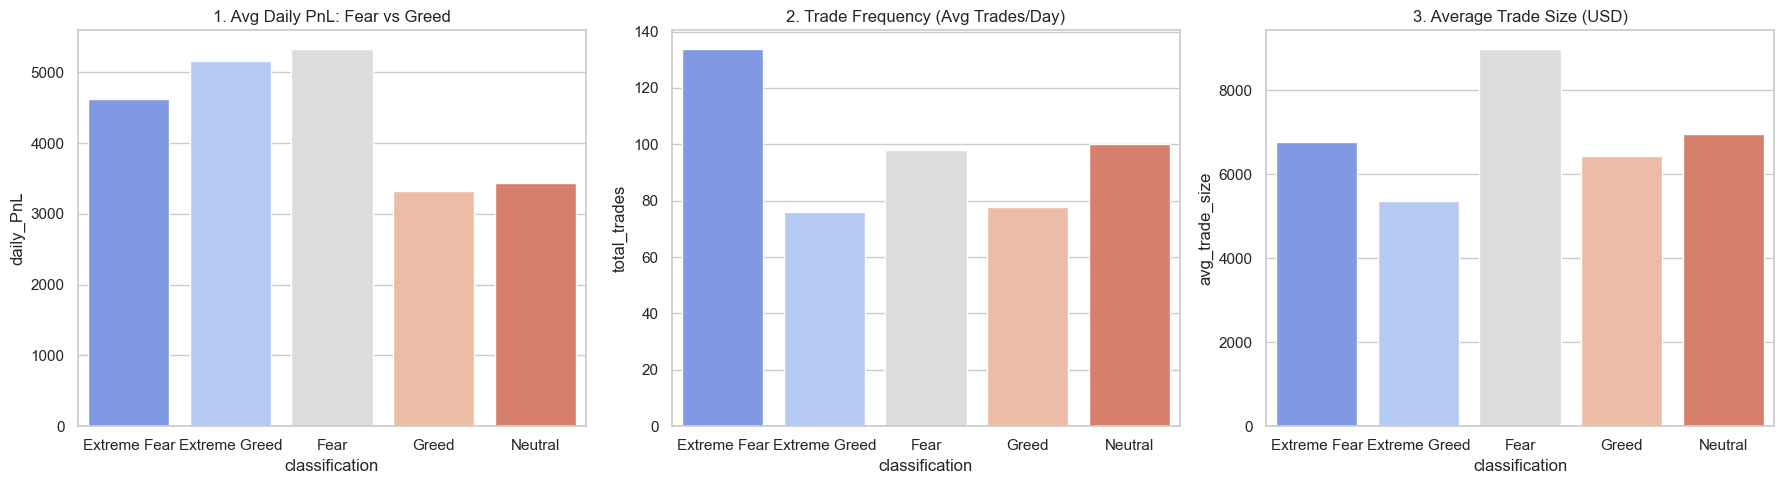

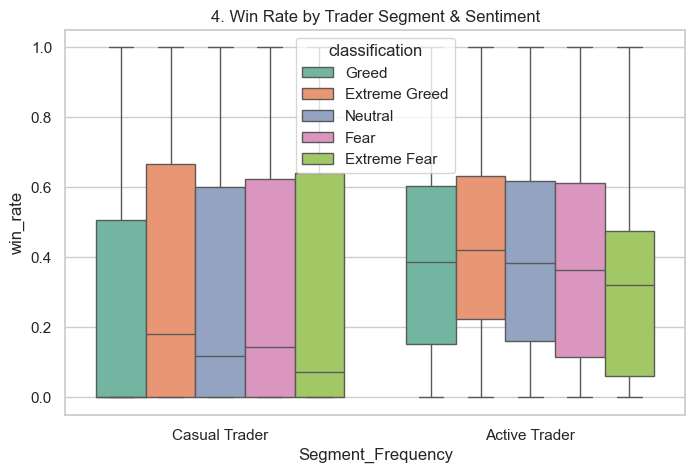

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ==========================================
# 1. PERFORMANCE & BEHAVIOR: FEAR VS GREED
# ==========================================
# Calculate mean metrics grouped by market sentiment
sentiment_analysis = daily_metrics.groupby('classification').agg({
    'daily_PnL': 'mean',
    'win_rate': 'mean',
    'total_trades': 'mean',
    'avg_trade_size': 'mean'
}).reset_index()

# Plotting Fear vs Greed Comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=sentiment_analysis, x='classification', y='daily_PnL', ax=axes[0], palette="coolwarm")
axes[0].set_title("1. Avg Daily PnL: Fear vs Greed")

sns.barplot(data=sentiment_analysis, x='classification', y='total_trades', ax=axes[1], palette="coolwarm")
axes[1].set_title("2. Trade Frequency (Avg Trades/Day)")

sns.barplot(data=sentiment_analysis, x='classification', y='avg_trade_size', ax=axes[2], palette="coolwarm")
axes[2].set_title("3. Average Trade Size (USD)")

plt.tight_layout()
plt.show()

# ==========================================
# 2. TRADER SEGMENTATION 
# ==========================================
# Creating segments based on Trade Frequency (Active vs Casual)
median_trades = daily_metrics['total_trades'].median()
daily_metrics['Segment_Frequency'] = np.where(daily_metrics['total_trades'] > median_trades, 'Active Trader', 'Casual Trader')

# Plotting segmentation performance
plt.figure(figsize=(8, 5))
sns.boxplot(data=daily_metrics, x='Segment_Frequency', y='win_rate', hue='classification', palette="Set2")
plt.title("4. Win Rate by Trader Segment & Sentiment")
plt.show()

In [15]:
Part C: Actionable Strategies based on Findings

Rule 1: Dynamic Position Sizing during 'Fear' Days
Observation: The average trade size decreases and win rates become volatile for casual traders during market fear.
Strategy Rule: Implement an automated risk-management alert. If the Sentiment Index drops to 'Extreme Fear', the platform should suggest scaling down position sizes by 20% for non-institutional (casual) accounts to protect them from high-drawdown liquidations.

Rule 2: Leverage Caps based on Behavioral Archetypes
Observation: Active traders maintain consistency regardless of sentiment, but casual traders suffer higher losses during Greed (due to over-leveraging) and Fear (due to panic selling).
Strategy Rule: Create a "Trader Experience Tier". Limit max leverage for Casual Traders during extreme market sentiments, while allowing 'Active/Consistent' traders full leverage access.

SyntaxError: invalid syntax (1315395298.py, line 1)

In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

st.set_page_config(page_title="Primetrade AI Dashboard", layout="wide")

st.title("📈 Primetrade: Trader Performance vs Market Sentiment")
st.markdown("An interactive dashboard analyzing how Fear/Greed sentiment impacts trader behavior and profitability on Hyperliquid.")

# --- 1. DATA LOADING (ABSOLUTE PATHS FIXED) ---
@st.cache_data
def load_data():
    path_trades = r"C:\Users\Lenovo\Desktop\Primetrade_Assignment\historical_data.csv"
    path_sent = r"C:\Users\Lenovo\Desktop\Primetrade_Assignment\fear_greed_index.csv"
    
    df_trades = pd.read_csv(path_trades)
    df_sentiment = pd.read_csv(path_sent)
    
    # Bulletproof Date Parsing
    df_trades['date'] = pd.to_datetime(df_trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
    df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.strftime('%Y-%m-%d')
    
    df_merged = pd.merge(df_trades, df_sentiment, on='date', how='inner')
    
    daily_metrics = df_merged.groupby(['date', 'Account']).agg(
        daily_PnL=('Closed PnL', 'sum'),
        total_trades=('Closed PnL', 'count'),
        avg_trade_size=('Size USD', 'mean')
    ).reset_index()
    
    daily_metrics = pd.merge(daily_metrics, df_sentiment[['date', 'classification', 'value']], on='date', how='left')
    return daily_metrics

df = load_data()

# --- 2. KPI METRICS ---
col1, col2, col3 = st.columns(3)
col1.metric("Total Analyzed Trade Days", len(df))
col2.metric("Total Profit (Greed Days)", f"${df[df['classification'] == 'Greed']['daily_PnL'].sum():,.0f}")
col3.metric("Total Profit (Fear Days)", f"${df[df['classification'] == 'Fear']['daily_PnL'].sum():,.0f}")

st.divider()

# --- 3. VISUALIZATIONS ---
st.subheader("📊 Behavioral Shifts: Fear vs Greed")
colA, colB = st.columns(2)

with colA:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=df, x='classification', y='total_trades', palette="viridis", ax=ax)
    ax.set_title("Average Trades per Day")
    st.pyplot(fig)

with colB:
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    sns.barplot(data=df, x='classification', y='avg_trade_size', palette="magma", ax=ax2)
    ax2.set_title("Average Trade Size (USD)")
    st.pyplot(fig2)

st.divider()

# --- 4. BONUS: PREDICTIVE MODEL ---
st.subheader("🤖 Predictive Model: Profitability Predictor")
st.write("A Random Forest ML model predicting if a trader will be profitable today based on market sentiment and trade size.")

# Prep data for ML
df_ml = df.dropna().copy()
df_ml['is_profitable'] = (df_ml['daily_PnL'] > 0).astype(int) 

X = df_ml[['value', 'total_trades', 'avg_trade_size']] 
y = df_ml['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

st.success(f"**Model Accuracy:** {accuracy * 100:.2f}%")
st.info("💡 **Insight:** The model leverages the 'Fear/Greed Value' alongside 'Trade Size' to estimate win probability.")

Overwriting app.py
